# MIS/MVC QAOA with LX and Grover mixers

This example uses the unified `MIS_MVC_Problem`, `MIS_MVC_InitialState`, and `VertexSubsetLXMixer` classes. The six-vertex house-with-tail graph is small enough for exact checks and has nonuniform degrees, making the degree-ordered LX construction visible.

In [1]:
import itertools

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from qiskit.quantum_info import Statevector

from qaoa import QAOA, utils
from qaoa.initialstates import MIS_MVC_InitialState
from qaoa.mixers import Grover, VertexSubsetLXMixer
from qaoa.problems import MIS_MVC_Problem

## Graph

Example from https://arxiv.org/abs/2607.27915

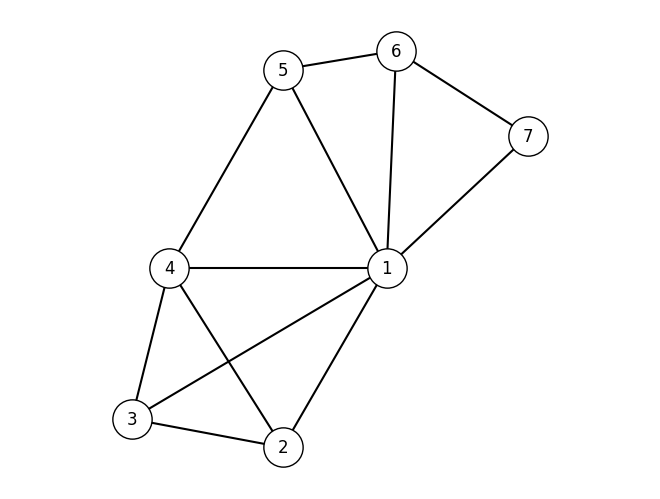

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Preserve node/qubit order: q0 -> node 1, ..., q6 -> node 7
G.add_nodes_from(range(1, 8))

G.add_edges_from([
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 5),
    (1, 6),
    (1, 7),
    (2, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
])

pos = {
    1: (0.0, 0.0),
    2: (-0.55, -0.95),
    3: (-1.35, -0.80),
    4: (-1.15, 0.0),
    5: (-0.55, 1.05),
    6: (0.05, 1.15),
    7: (0.75, 0.70),
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    edgecolors="black",
    node_size=800,
    width=1.5,
)

plt.axis("equal")
plt.show()

## Choose MIS or MVC and construct the components

Set `problem_kind` to `"mis"` or `"mvc"`. The initial state uses a fixed-angle LX sweep.

In [3]:
problem_kind = "mis"  # change to "mvc"
initial_angle = np.pi / 4

problem = MIS_MVC_Problem(G, problem_kind=problem_kind)
initial_state = MIS_MVC_InitialState(
    G,
    problem_kind=problem_kind,
    angle=initial_angle,
    phase_correct=True,
)
lx_mixer = VertexSubsetLXMixer(
    G,
    problem_kind=problem_kind,
    multi_angle=True,
)
grover_mixer = Grover(initial_state)

print("Problem:", problem_kind.upper())
print("Degree-ordered vertices:", tuple(x + 1 for x in initial_state.vertex_order))
print("LX parameter order (original node labels):", lx_mixer.parameter_nodes)

Problem: MIS
Degree-ordered vertices: (1, 4, 2, 3, 5, 6, 7)
LX parameter order (original node labels): (1, 4, 2, 3, 5, 6, 7)


## Inspect the circuits

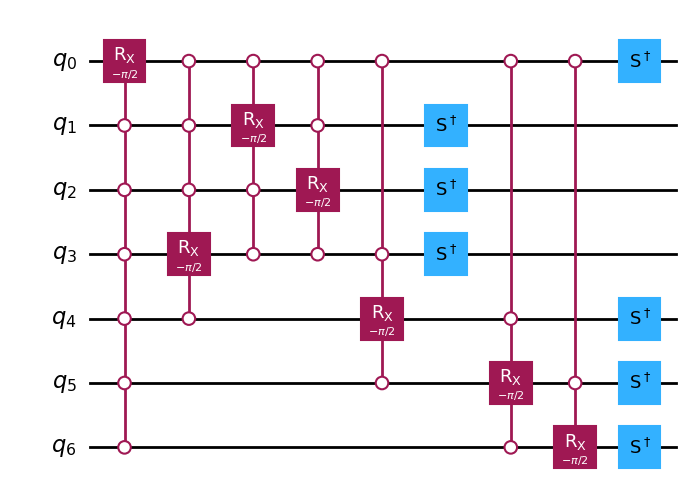

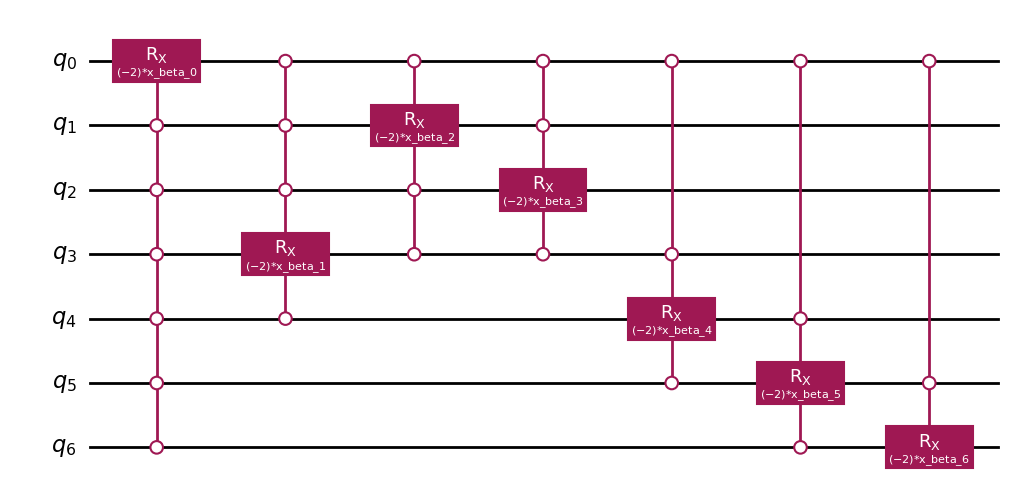

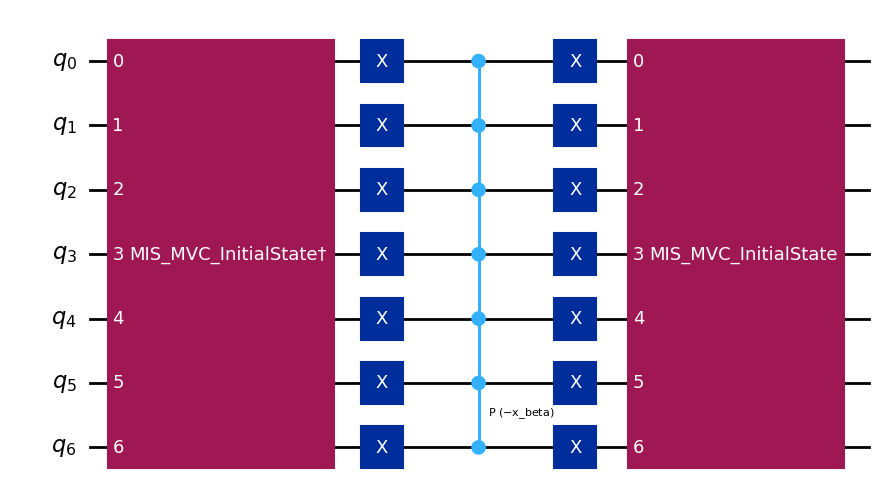

In [4]:
lx_mixer.create_circuit()
grover_mixer.create_circuit()

display(initial_state.circuit.draw("mpl", fold=-1))
display(lx_mixer.circuit.draw("mpl", fold=-1))
display(grover_mixer.circuit.draw("mpl", fold=-1))

## Run QAOA

Choose `"lx"` or `"grover"`. The coarse grid keeps this example quick; increase its resolution and the shot count for a final experiment.

2026-08-31 12:14:20 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:20 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:20 [info     ] circuits: 200                  file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:20 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:25 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:25 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape


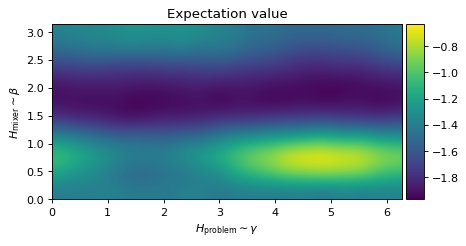

In [5]:
qaoa_lx = QAOA(
    problem=problem,
    mixer=lx_mixer,
    initialstate=initial_state,
    interpolate=True,
    shots=1000,
)
qaoa_lx.sample_cost_landscape(
    angles={"gamma": [0, 2*np.pi, 20], "beta": [0, np.pi, 10]}
)
_=utils.plot_E(qaoa_lx)

2026-08-31 12:14:25 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:25 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:25 [info     ] circuits: 400                  file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:25 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:38 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-08-31 12:14:38 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape


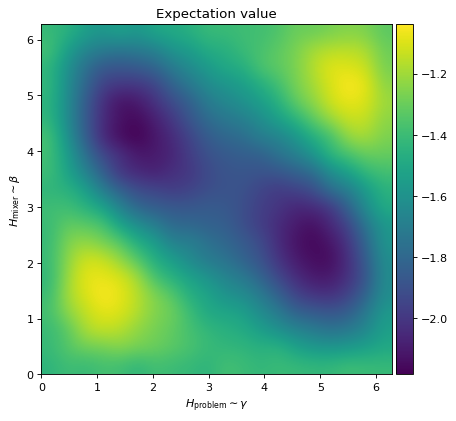

In [6]:
qaoa_grover = QAOA(
    problem=problem,
    mixer=grover_mixer,
    initialstate=initial_state,
    interpolate=True,
    shots=1000,
)
qaoa_grover.sample_cost_landscape()
_=utils.plot_E(qaoa_grover)

In [7]:
maxdepth=5
qaoa_lx.optimize(depth=maxdepth)

2026-08-31 12:14:41 [info     ] energy(depth 1) = -2.1540000000000004 file=qaoa.qaoa func=optimize
2026-08-31 12:14:46 [info     ] energy(depth 2) = -2.4479999999999995 file=qaoa.qaoa func=optimize
2026-08-31 12:14:56 [info     ] energy(depth 3) = -2.5900000000000003 file=qaoa.qaoa func=optimize
2026-08-31 12:15:13 [info     ] energy(depth 4) = -2.5220000000000002 file=qaoa.qaoa func=optimize
2026-08-31 12:15:39 [info     ] energy(depth 5) = -2.7009999999999996 file=qaoa.qaoa func=optimize


In [8]:
qaoa_grover.optimize(depth=maxdepth)

2026-08-31 12:15:41 [info     ] energy(depth 1) = -2.1950000000000003 file=qaoa.qaoa func=optimize
2026-08-31 12:15:44 [info     ] energy(depth 2) = -2.3780000000000006 file=qaoa.qaoa func=optimize
2026-08-31 12:15:49 [info     ] energy(depth 3) = -2.538       file=qaoa.qaoa func=optimize
2026-08-31 12:15:56 [info     ] energy(depth 4) = -2.866       file=qaoa.qaoa func=optimize
2026-08-31 12:16:06 [info     ] energy(depth 5) = -2.983       file=qaoa.qaoa func=optimize


In [9]:
objmin, objmax = problem.objective_bounds()

## Decode the QAOA result and compare with the exact optimum

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='depth', ylabel='appr. ratio'>)

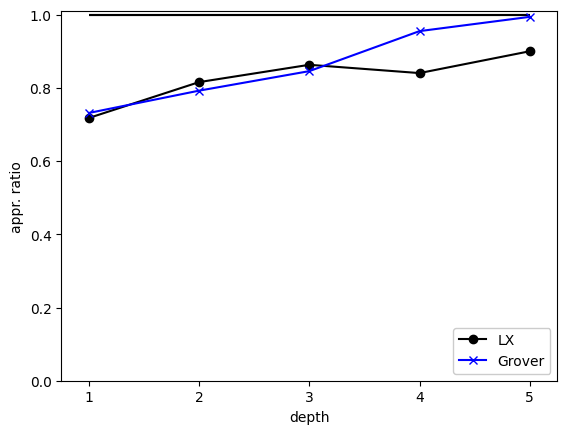

In [10]:
fig=plt.figure()
utils.plot_ApproximationRatio(qaoa_lx, maxdepth, objmin, objmax, label='LX', style='k-o', fig=fig)
utils.plot_ApproximationRatio(qaoa_grover, maxdepth, objmin, objmax, label='Grover', style='b-x', fig=fig)